In [1]:
import os
import warnings
import pandas as pd
import numpy as np
from datetime import datetime

warnings.filterwarnings("ignore")

In [2]:
SUPPORTED_STOCKS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA"
]

RESULTS_DIR = "../results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results folder is ready.")

Results folder is ready.


In [3]:
def load_stock_data(ticker):

    print("\n" + "="*70)
    print(f"TRADING SIGNAL GENERATION : {ticker}")
    print("="*70)

    stock = pd.read_csv(
        f"../data/{ticker}/processed/processed_stock_data.csv"
    )

    forecast = pd.read_csv(
        f"../reports/{ticker}/prophet_forecast.csv"
    )

    sentiment = pd.read_csv(
        f"../reports/{ticker}/news_sentiment.csv"
    )

    return stock, forecast, sentiment

In [4]:
def show_dataset_info(stock, forecast, sentiment):

    print("\nProcessed Stock Data")
    print(stock.head())

    print("\nForecast Data")
    print(forecast.head())

    print("\nSentiment Data")
    print(sentiment.head())

In [5]:
def extract_market_values(stock, forecast):

    current_price = stock["Close"].iloc[-1]

    predicted_price = forecast["yhat"].iloc[-1]

    sma20 = stock["SMA20"].iloc[-1]

    sma50 = stock["SMA50"].iloc[-1]

    rsi = stock["RSI"].iloc[-1]

    macd = stock["MACD"].iloc[-1]

    macd_signal = stock["MACD_Signal"].iloc[-1]

    return (
        current_price,
        predicted_price,
        sma20,
        sma50,
        rsi,
        macd,
        macd_signal
    )

In [6]:
def calculate_sentiment(sentiment):

    avg_polarity = sentiment["Polarity"].mean()

    if avg_polarity > 0.20:
        sentiment_signal = "Positive"
        sentiment_score = 2

    elif avg_polarity < -0.20:
        sentiment_signal = "Negative"
        sentiment_score = -2

    else:
        sentiment_signal = "Neutral"
        sentiment_score = 0

    return avg_polarity, sentiment_signal, sentiment_score

In [7]:
def technical_analysis(current_price,
                       predicted_price,
                       sma20,
                       sma50,
                       rsi,
                       macd,
                       macd_signal):

    score = 0

    if predicted_price > current_price:
        score += 2
    else:
        score -= 2

    if sma20 > sma50:
        score += 1
    else:
        score -= 1

    if rsi < 30:
        score += 2

    elif rsi > 70:
        score -= 2

    if macd > macd_signal:
        score += 1
    else:
        score -= 1

    return score

In [8]:
def generate_signal(total_score):

    if total_score >= 4:
        signal = "BUY"

    elif total_score <= -2:
        signal = "SELL"

    else:
        signal = "HOLD"

    return signal

In [9]:
def confidence_score(total_score):

    confidence = min(
        abs(total_score) * 20,
        100
    )

    return confidence

In [10]:
def create_report(ticker,
                  current_price,
                  predicted_price,
                  avg_polarity,
                  total_score,
                  signal,
                  confidence):

    report = pd.DataFrame({

        "Ticker":[ticker],

        "Current Price":[round(current_price,2)],

        "Predicted Price":[round(predicted_price,2)],

        "Average Sentiment":[round(avg_polarity,3)],

        "Trading Score":[total_score],

        "Recommendation":[signal],

        "Confidence (%)":[confidence],

        "Generated On":[datetime.now()]

    })

    return report

In [11]:
def save_report(report, ticker):

    output = os.path.join(
        RESULTS_DIR,
        f"{ticker}_recommendation.csv"
    )

    report.to_csv(
        output,
        index=False
    )

    print(f"Saved : {output}")

In [12]:
def display_report(report):

    print("\nTrading Recommendation")
    print("-"*60)

    print(report)

In [13]:
all_reports = []

for ticker in SUPPORTED_STOCKS:

    stock, forecast, sentiment = load_stock_data(ticker)

    show_dataset_info(
        stock,
        forecast,
        sentiment
    )

    (
        current_price,
        predicted_price,
        sma20,
        sma50,
        rsi,
        macd,
        macd_signal
    ) = extract_market_values(
        stock,
        forecast
    )

    (
        avg_polarity,
        sentiment_signal,
        sentiment_score
    ) = calculate_sentiment(
        sentiment
    )

    technical_score = technical_analysis(
        current_price,
        predicted_price,
        sma20,
        sma50,
        rsi,
        macd,
        macd_signal
    )

    total_score = technical_score + sentiment_score

    signal = generate_signal(total_score)

    confidence = confidence_score(total_score)

    report = create_report(
        ticker,
        current_price,
        predicted_price,
        avg_polarity,
        total_score,
        signal,
        confidence
    )

    display_report(report)

    save_report(report, ticker)

    all_reports.append(report)

print("\nTrading Signal Generation Completed Successfully!")


TRADING SIGNAL GENERATION : AAPL

Processed Stock Data
         Date   Adj Close       Close        High         Low        Open  \
0  2023-03-15  150.666458  152.990005  153.250000  149.919998  151.190002   
1  2023-03-16  153.483017  155.850006  156.460007  151.639999  152.160004   
2  2023-03-17  152.645935  155.000000  156.740005  154.279999  156.080002   
3  2023-03-20  155.009476  157.399994  157.820007  154.149994  155.070007   
4  2023-03-21  156.860947  159.279999  159.399994  156.539993  157.320007   

     Volume Symbol     AssetType        Name  ... MACD_Hist   BB_Middle  \
0  77167900   AAPL  Common Stock  Apple Inc.  ... -0.177596  150.305501   
1  76161100   AAPL  Common Stock  Apple Inc.  ...  0.076450  150.331501   
2  98944600   AAPL  Common Stock  Apple Inc.  ...  0.160352  150.396001   
3  73641400   AAPL  Common Stock  Apple Inc.  ...  0.340255  150.638500   
4  73938300   AAPL  Common Stock  Apple Inc.  ...  0.536937  151.178500   

     BB_Upper    BB_Lower Dail

In [14]:
combined_report = pd.concat(
    all_reports,
    ignore_index=True
)

combined_report.to_csv(
    os.path.join(
        RESULTS_DIR,
        "all_stock_recommendations.csv"
    ),
    index=False
)

print("\nCombined Recommendation Report")
print("-"*60)

print(combined_report)


Combined Recommendation Report
------------------------------------------------------------
  Ticker  Current Price  Predicted Price  Average Sentiment  Trading Score  \
0   AAPL         340.08           302.69              0.132             -2   
1   MSFT         393.35           520.93              0.114              2   
2  GOOGL         333.71           333.44              0.143             -4   
3   AMZN         230.86           246.30              0.152              0   
4   NVDA         197.01           203.17              0.122              0   

  Recommendation  Confidence (%)               Generated On  
0           SELL              40 2026-07-29 20:34:35.131345  
1           HOLD              40 2026-07-29 20:34:35.678137  
2           SELL              80 2026-07-29 20:34:36.043325  
3           HOLD               0 2026-07-29 20:34:36.255701  
4           HOLD               0 2026-07-29 20:34:36.461338  



Recommendation Summary
Recommendation
HOLD    3
SELL    2
Name: count, dtype: int64

Lab 9 Completed Successfully!


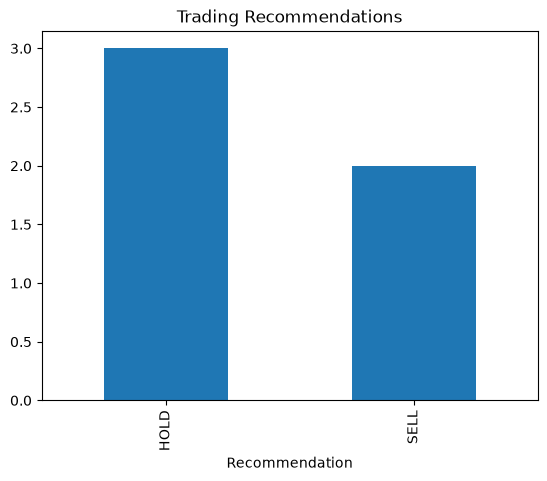

In [15]:
summary = combined_report["Recommendation"].value_counts()

print("\nRecommendation Summary")
print(summary)

summary.plot(
    kind="bar",
    title="Trading Recommendations"
)

print("\nLab 9 Completed Successfully!")